In [ ]:
# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Step 3: Data Preprocessing

# Remove rows with missing product descriptions
df = df.dropna(subset=['Description'])

# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantities
df = df[df['Quantity'] > 0]

# Clean product names
df['Description'] = df['Description'].str.strip()

print("After preprocessing:")
print("Records:", len(df))
print("Unique transactions:", df['InvoiceNo'].nunique())
print("Unique products:", df['Description'].nunique())

df[['InvoiceNo', 'Description', 'Quantity']].head()

After preprocessing:
Records: 530693
Unique transactions: 20136
Unique products: 4065


,InvoiceNo,Description,Quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6


In [ ]:
# Step 4: Select Frequently Purchased Products

# Count how many transactions contain each product
product_frequency = (
    df.groupby('Description')['InvoiceNo']
      .nunique()
      .sort_values(ascending=False)
)

# Keep only the top 100 products
top_products = product_frequency.head(100).index

print("Total unique products:", len(product_frequency))
print("Products selected for MBA:", len(top_products))

# Keep only transactions containing these products
df_mba = df[df['Description'].isin(top_products)].copy()

print("Records for MBA:", len(df_mba))
print("Transactions for MBA:", df_mba['InvoiceNo'].nunique())


Total unique products: 4065
Products selected for MBA: 100
Records for MBA: 97706
Transactions for MBA: 16104


In [ ]:
# Step 5: Create Optimized Transaction Basket

basket = (
    df_mba.groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

# Convert quantities into True/False
basket = basket > 0

print("Basket created successfully!")
print("Basket shape:", basket.shape)

basket.head()

Basket created successfully!
Basket shape: (16104, 100)


Description,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE PINK,ALARM CLOCK BAKELIKE RED,ANTIQUE SILVER T-LIGHT GLASS,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,CHARLOTTE BAG PINK POLKADOT,CHARLOTTE BAG SUKI DESIGN,...,SPOTTY BUNTING,STRAWBERRY CERAMIC TRINKET BOX,STRAWBERRY CHARLOTTE BAG,VICTORIAN GLASS HANGING T-LIGHT,VINTAGE SNAP CARDS,WHITE HANGING HEART T-LIGHT HOLDER,WOOD BLACK BOARD ANT WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,WOODLAND CHARLOTTE BAG
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
536367,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536370,False,False,True,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536371,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Step 6: Apply Apriori Algorithm

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

print("Frequent itemsets found:")
print(frequent_itemsets.head(10))

print("\nTotal frequent itemsets:", len(frequent_itemsets))

Frequent itemsets found:
    support                         itemsets
0  0.059302         (6 RIBBONS RUSTIC CHARM)
1  0.051416    (60 TEATIME FAIRY CAKE CASES)
2  0.060854     (ALARM CLOCK BAKELIKE GREEN)
3  0.048621      (ALARM CLOCK BAKELIKE PINK)
4  0.065263       (ALARM CLOCK BAKELIKE RED)
5  0.042784   (ANTIQUE SILVER T-LIGHT GLASS)
6  0.090350  (ASSORTED COLOUR BIRD ORNAMENT)
7  0.057998   (BAKING SET 9 PIECE RETROSPOT)
8  0.046138    (CHARLOTTE BAG PINK POLKADOT)
9  0.054769      (CHARLOTTE BAG SUKI DESIGN)

Total frequent itemsets: 258


In [ ]:
# Step 7: Generate Association Rules

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

# Select important columns
rules = rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
]

# Sort rules by lift
rules = rules.sort_values(
    by='lift',
    ascending=False
)

print("Total association rules:", len(rules))

rules.head(10)

Total association rules: 295


,antecedents,consequents,support,confidence,lift
241,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.033656,0.707572,14.836896
236,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.033656,0.705729,14.836896
222,(STRAWBERRY CHARLOTTE BAG),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.020740,0.462604,14.693832
221,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",(STRAWBERRY CHARLOTTE BAG),0.020740,0.658777,14.693832
212,(CHARLOTTE BAG PINK POLKADOT),"(STRAWBERRY CHARLOTTE BAG, RED RETROSPOT CHARL...",0.020243,0.438762,14.538724
207,"(STRAWBERRY CHARLOTTE BAG, RED RETROSPOT CHARL...",(CHARLOTTE BAG PINK POLKADOT),0.020243,0.670782,14.538724
290,"(WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOT...",(STRAWBERRY CHARLOTTE BAG),0.020306,0.646245,14.414308
293,(STRAWBERRY CHARLOTTE BAG),"(WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOT...",0.020306,0.452909,14.414308
239,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.033656,0.533990,14.356223
238,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.033656,0.904841,14.356223


In [ ]:
# Step 8: Display Top Association Rules

# Convert itemsets into readable text
rules_display = rules.copy()

rules_display['antecedents'] = rules_display['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

rules_display['consequents'] = rules_display['consequents'].apply(
    lambda x: ', '.join(list(x))
)

# Display top 10 rules
top_rules = rules_display.head(10).copy()

# Round numerical values
top_rules['support'] = top_rules['support'].round(4)
top_rules['confidence'] = top_rules['confidence'].round(4)
top_rules['lift'] = top_rules['lift'].round(4)

print("Top 10 Association Rules:")
top_rules

Top 10 Association Rules:


,antecedents,consequents,support,confidence,lift
241,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.0337,0.7076,14.8369
236,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.0337,0.7057,14.8369
222,STRAWBERRY CHARLOTTE BAG,"RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SUK...",0.0207,0.4626,14.6938
221,"RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SUK...",STRAWBERRY CHARLOTTE BAG,0.0207,0.6588,14.6938
212,CHARLOTTE BAG PINK POLKADOT,"STRAWBERRY CHARLOTTE BAG, RED RETROSPOT CHARLO...",0.0202,0.4388,14.5387
207,"STRAWBERRY CHARLOTTE BAG, RED RETROSPOT CHARLO...",CHARLOTTE BAG PINK POLKADOT,0.0202,0.6708,14.5387
290,"WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOTT...",STRAWBERRY CHARLOTTE BAG,0.0203,0.6462,14.4143
293,STRAWBERRY CHARLOTTE BAG,"WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOTT...",0.0203,0.4529,14.4143
239,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.0337,0.5340,14.3562
238,"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.0337,0.9048,14.3562


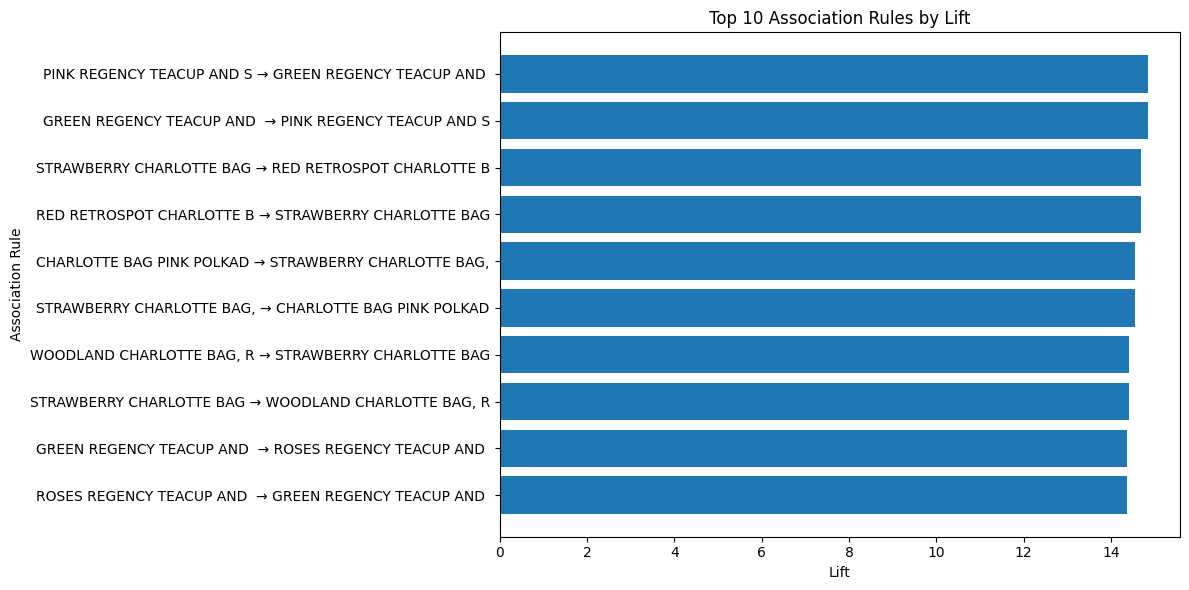

In [ ]:
# Step 9: Visualize Top Association Rules

import matplotlib.pyplot as plt

# Create rule labels
plot_rules = rules_display.head(10).copy()

plot_rules['rule'] = (
    plot_rules['antecedents'].str[:25]
    + " → "
    + plot_rules['consequents'].str[:25]
)

# Create bar chart
plt.figure(figsize=(12, 6))

plt.barh(
    plot_rules['rule'],
    plot_rules['lift']
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()